# Foil sections

Get and set **control points**, **geometric parameters** (tc, camber, LE radius, ...)
and **structural parameters** (area, Ixx, ...) of a foil section.

Open a project in the GUI first — the SDK works on the same session.

In [ ]:
from pytakeoff import TakeoffClient

API_KEY = "tk_xxxxxxxx_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # get a key in the GUI (Account -> API Keys) or run: python -m pytakeoff

client = TakeoffClient(api_key=API_KEY)
print(f"Connected to {client.base_url} as {client.username}")

project = client.projects.current() or client.projects.open(client.projects.list()[0]["name"])
project

Connected to http://localhost:8000 as nicopeis


Project('260622_Test_beach_toy')

## Pick a section

In [2]:
import matplotlib.pyplot as plt

section = project.foil_sections()[0]
section

FoilSection('foil_section_1', id='e7213a74-475c-47d2-8c09-d6d3a52ff742')

## The shape: outline and control points

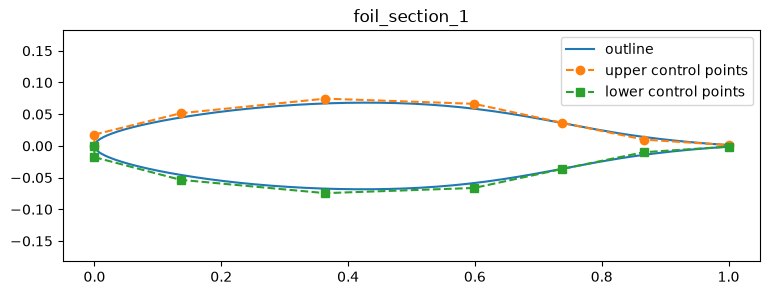

In [3]:
cp = section.control_points()          # {"upper", "lower", "degree", "n_coefs"}
xy = section.points()                  # computed outline

plt.figure(figsize=(9, 3))
plt.plot(*zip(*xy), "-", label="outline")
plt.plot(*zip(*cp["upper"]), "o--", label="upper control points")
plt.plot(*zip(*cp["lower"]), "s--", label="lower control points")
plt.axis("equal"); plt.legend(); plt.title(section.name)
plt.show()

## Geometric & structural parameters

In [4]:
print("geometry: ", section.geometry())    # tc / camber in % of chord
print("structure:", section.structure())

geometry:  {'tc': 13.65768690672024, 'camber': -0.054699762424100656, 'le_radius': 0.6231083292835923, 'te_thickness': 0.25199979996264144, 'te_angle': -0.0}
structure: {'area': 0.08735442463407636, 'Ixx': 9.259977361332937e-05, 'SMx': 0.001354591472161516, 'J': 0.0003703187424827189, 'centroid': [0.3296364242120025, -0.00015992485600918845]}


## Set a parameter — make it 20% thicker

Parametric setters refit the B-spline and return the achieved values.

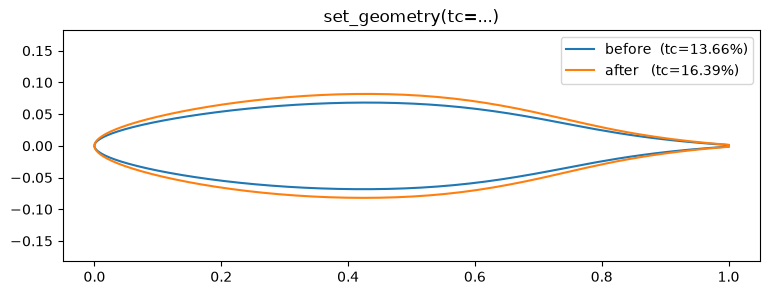

In [5]:
geo = section.geometry()
outline_before = section.points()

section.set_geometry(tc=geo["tc"] * 1.2)

plt.figure(figsize=(9, 3))
plt.plot(*zip(*outline_before), label=f"before  (tc={geo['tc']:.2f}%)")
plt.plot(*zip(*section.points()), label=f"after   (tc={section.geometry()['tc']:.2f}%)")
plt.axis("equal"); plt.legend(); plt.title("set_geometry(tc=...)")
plt.show()

## Restore the original shape exactly

Setting the saved control points back is an exact restore (nothing was saved to disk).

In [ ]:
section.set_control_points(upper=cp["upper"], lower=cp["lower"])
print("tc back to", round(section.geometry()["tc"], 3), "%")
client.close()

ConnectionClosed: Connection lost (server restarted? machine slept?) — the next call reconnects automatically

: 